# 🧹 Limpeza dos Dados

## Origem dos Dados

Os dados iniciais foram obtidos através do consumo da API do Dev.to, gerando a base artigos.csv. Em seguida, foi realizado um filtro para manter somente os artigos em inglês, gerando a base artigos_en.csv.

A partir dessa base, foi extraída uma amostra para validação da classificação dos textos, verificando se o conteúdo dos artigos estava de acordo com suas respectivas categorias e subcategorias. Após essa análise, foram removidos os registros das subcategorias que apresentaram baixa aderência entre o conteúdo do texto e sua classificação, resultando na base artigos_en_filtrado.csv. Essa base, contendo 1.851 registros, será utilizada como entrada para a etapa de limpeza dos dados.

## Objetivo

Este notebook tem como objetivo realizar a limpeza e preparação da base artigos_en_filtrado.csv, removendo inconsistências nos dados e realizando os tratamentos necessários para gerar a base final base_techmind.csv, que será utilizada nas próximas etapas do projeto.

## Bibliotecas

In [1]:
# Instalações realizadas 
# pip install regex
# pip install spacy --break-system-packages
# pip install click --break-system-packages
# !python -m spacy download en_core_web_sm       # Baixa o modelo de linguagem em inglês 

In [2]:
# Importa as Bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import regex as re
import spacy

from langdetect import detect, DetectorFactory

## Obtem Dados

In [3]:
# Carregando dados 
df = pd.read_csv('../dados/artigos_en_filtrado.csv')
df.head(1)

,categoria,collection_id,comments_count,created_at,crossposted_at,description,edited_at,flare_tag,id,language,...,published_timestamp,readable_publish_date,reading_time_minutes,subcategoria,subforem_id,tag_list,tags,texto,title,type_of
0,Frontend,NaN,0,2026-07-18T19:29:08Z,NaN,Choosing a state management library feels a bi...,2026-07-18T19:31:43Z,NaN,4175536,en,...,2026-07-18T19:29:08Z,Jul 18,3,frontend,1.0,"['architecture', 'frontend', 'react', 'typescr...","architecture, frontend, react, typescript",Choosing a state management library feels a bi...,Stop Over Engineering Your Frontend State: A D...,article


## Conhecendo os Dados

In [4]:
# Conhecendo dados e estrutura
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1851 entries, 0 to 1850
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   categoria                 1851 non-null   object 
 1   collection_id             150 non-null    float64
 2   comments_count            1851 non-null   int64  
 3   created_at                1851 non-null   object 
 4   crossposted_at            15 non-null     object 
 5   description               1851 non-null   object 
 6   edited_at                 322 non-null    object 
 7   flare_tag                 85 non-null     object 
 8   id                        1851 non-null   int64  
 9   language                  1851 non-null   object 
 10  last_comment_at           1851 non-null   object 
 11  positive_reactions_count  1851 non-null   int64  
 12  public_reactions_count    1851 non-null   int64  
 13  published_at              1851 non-null   object 
 14  publishe

## Análise Exploratória

### Redução inicial de Colunas

In [5]:
# Remoção inicial de colunas
df = df[['id', 'categoria', 'subcategoria', 'texto', 'tags']]
df.shape

(1851, 5)

### Categorias

In [6]:
# Distribuição das categorias
df['categoria'].value_counts()

categoria
Security       346
Frontend       341
Backend        338
Database       324
Cloud          287
DataScience    215
Name: count, dtype: int64

### Valores duplicados por linha

In [7]:
# Verificando registros duplicados por linha
df.duplicated().sum()

np.int64(0)

### Valores duplicados por id

In [8]:
# Quantidade de registros duplicados por id 
df['id'].duplicated().sum()

np.int64(253)

In [9]:
# Verificando registros com ids duplicados
df[df['id'].duplicated(keep=False)].sort_values('id').head(6)

,id,categoria,subcategoria,texto,tags
857,3450296,Cloud,azure,creating a folder and initializing github for ...,"devops, azure, cloud, cloudcomputing"
718,3450296,Cloud,cloud,creating a folder and initializing github for ...,"devops, azure, cloud, cloudcomputing"
816,3509884,Cloud,aws,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
377,3509884,Backend,backend,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
1704,3790359,DataScience,machinelearning,"---\r\ndescription: ""SDAR claims it beats GRPO...","aws, machinelearning, mlops, reinforcementlear..."
800,3790359,Cloud,aws,"---\r\ndescription: ""SDAR claims it beats GRPO...","aws, machinelearning, mlops, reinforcementlear..."


Há registros duplicados por id com a mesma categoria e texto. Isso ocorre porque o registro é obtida via api através da subcategoria e cada artigo pode ter até 4 tags diferentes. Nesses casos, um dos registros será descartado. 

Há registros duplicado por id, porém com categorias diferentes. Verificar quantos casos de cada tipo.

### Valores duplicados por id e texto iguais com categoria diferente

In [10]:
# Quantidade de conflitos (id igual, texto igual e categoria diferente)
conflitos_categoria = df[df['id'].duplicated(keep=False)].groupby('id')['categoria'].nunique()
ids_conflito = conflitos_categoria[conflitos_categoria > 1].index

len(ids_conflito)

71

In [11]:
# Verificando registros com conflitos
df[df['id'].isin(ids_conflito)].sort_values('id').head(6)

,id,categoria,subcategoria,texto,tags
377,3509884,Backend,backend,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
816,3509884,Cloud,aws,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
800,3790359,Cloud,aws,"---\r\ndescription: ""SDAR claims it beats GRPO...","aws, machinelearning, mlops, reinforcementlear..."
1704,3790359,DataScience,machinelearning,"---\r\ndescription: ""SDAR claims it beats GRPO...","aws, machinelearning, mlops, reinforcementlear..."
1297,3965827,Security,security,"---\r\ntitle: ""Create and secure webhooks with...","api, webhooks, security, devtools"
511,3965827,Backend,api,"---\r\ntitle: ""Create and secure webhooks with...","api, webhooks, security, devtools"


São 71 casos com ids iguais e categorias diferentes 

In [12]:
# Quantidade por categoria (entre os registros em conflito)
df[df['id'].isin(ids_conflito)]['categoria'].value_counts()

categoria
Backend        34
Frontend       27
Security       26
DataScience    24
Database       23
Cloud          19
Name: count, dtype: int64

In [13]:
# Quantidade por subcategoria (entre os registros em conflito)
df[df['id'].isin(ids_conflito)]['subcategoria'].value_counts()

subcategoria
security           21
python             17
api                15
aws                12
backend            11
typescript         11
javascript         10
database            9
postgres            7
machinelearning     6
sql                 5
nextjs              5
cloud               5
cybersecurity       4
php                 4
java                3
springboot          1
react               1
azure               1
docker              1
nosql               1
mongodb             1
datascience         1
infosec             1
Name: count, dtype: int64

In [14]:
# Quantas vezes aparece o mesmo id 
contagem_por_id = df[df['id'].isin(ids_conflito)]['id'].value_counts()
contagem_por_id.value_counts()

count
2    61
3     9
4     1
Name: count, dtype: int64

In [15]:
# Quantidade total de registros envolvidos em conflito
len(df[df['id'].isin(ids_conflito)])

153

In [16]:
# Verificando se o texto também é igual nos casos de conflito de categoria
df[df['id'].isin(ids_conflito)].groupby('id')['texto'].nunique().value_counts()

texto
1    66
2     5
Name: count, dtype: int64

São 66 textos com id igual, texto igual e categoria diferente
 
São 5 textos com id igual, texto e categoria diferente

In [17]:
# Ids com conflito de categoria E texto diferente
ids_texto_diferente = df[df['id'].isin(ids_conflito)].groupby('id')['texto'].nunique()
ids_texto_diferente = ids_texto_diferente[ids_texto_diferente > 1].index

df[df['id'].isin(ids_texto_diferente)].sort_values('id')

,id,categoria,subcategoria,texto,tags
56,4161077,Frontend,javascript,"On 2026-07-05, re-verifying the numbers before...","security, eslint, devsecops, javascript"
1302,4161077,Security,security,"On 2026-07-05, re-verifying the numbers before...","security, eslint, devsecops, javascript"
60,4176288,Frontend,javascript,A test can be 95% accurate and still be wrong ...,"security, devsecops, node, javascript"
1301,4176288,Security,security,A test can be 95% accurate and still be wrong ...,"security, devsecops, node, javascript"
57,4176290,Frontend,javascript,"In 1943, the U.S. Navy studied the bombers ret...","security, devsecops, node, javascript"
1299,4176290,Security,security,"In 1943, the U.S. Navy studied the bombers ret...","security, devsecops, node, javascript"
58,4176293,Frontend,javascript,A benchmark score going up is not evidence tha...,"security, devsecops, node, javascript"
1303,4176293,Security,security,A benchmark score going up is not evidence tha...,"security, devsecops, node, javascript"
59,4176294,Frontend,javascript,Two radiologists read the same 100 screening m...,"security, devsecops, node, javascript"
1311,4176294,Security,security,Two radiologists read the same 100 screening m...,"security, devsecops, node, javascript"


Aparentemente os textos são iguais 

In [18]:
# Verificando a quantidade de caracteres 
df[df['id'].isin(ids_texto_diferente)].groupby('id')['texto'].apply(lambda x: x.str.len().tolist())

id
4161077    [12080, 13036]
4176288    [10909, 11128]
4176290    [11589, 12211]
4176293    [11186, 11635]
4176294    [11123, 11603]
Name: texto, dtype: object

In [19]:
print(df.loc[56, 'texto'])

On 2026-07-05, re-verifying the numbers before publishing the 17-plugin benchmark, `eslint-plugin-unicorn` came back 0 of 40 — a suspiciously clean zero that would have read as proof a well-regarded plugin was worthless. It wasn't: a stale Node version in my shell had silently swallowed the run, and the real number was 22 of 40, F1 51.8% (the full forensic walkthrough lives in [Bias in Measurement](https://ofriperetz.dev/articles/bias-in-measurement#the-unicorn-incident); this article is about the process that made me go looking for it).

That's the kind of mistake a vendor benchmark doesn't usually surface — vendors don't go looking for ways their own test caught nothing. Every ESLint benchmark on this site compares my own plugins to competitors, and I'm the one who decides what counts as a bug — which means every benchmark from a plugin author, including this one, has that exact problem. **A benchmark that's only ever been run once, by the person who built the tool it favors, hasn't 

In [20]:
print(df.loc[1302, 'texto'])

On 2026-07-05, re-verifying the numbers before publishing the 17-plugin benchmark, `eslint-plugin-unicorn` came back 0 of 40 — a suspiciously clean zero that would have read as proof a well-regarded plugin was worthless. It wasn't: a stale Node version in my shell had silently swallowed the run, and the real number was 22 of 40, F1 51.8% (the full forensic walkthrough lives in [Bias in Measurement](https://ofriperetz.dev/go/bias-in-measurement?utm_source=devto&from=i-built-what-i-benchmark-heres-how-i-try-not-to-cheat#the-unicorn-incident); this article is about the process that made me go looking for it).

That's the kind of mistake a vendor benchmark doesn't usually surface — vendors don't go looking for ways their own test caught nothing. Every ESLint benchmark on this site compares my own plugins to competitors, and I'm the one who decides what counts as a bug — which means every benchmark from a plugin author, including this one, has that exact problem. **A benchmark that's only e

A diferença esta nos links e não no texto do artigo. Consideramos então 71 registros com id igual, texto igual e categorias diferentes

In [21]:
# Verificando registros com mais de 2 id´s iguais e categorias diferentes 
ids_3_mais = contagem_por_id[contagem_por_id > 2].index
df[df['id'].isin(ids_3_mais)].sort_values('id')

,id,categoria,subcategoria,texto,tags
725,4149763,Cloud,cloud,## Why you almost never want to run your own d...,"database, sql, nosql, cloud"
1178,4149763,Database,sql,## Why you almost never want to run your own d...,"database, sql, nosql, cloud"
1081,4149763,Database,nosql,## Why you almost never want to run your own d...,"database, sql, nosql, cloud"
387,4160310,Backend,backend,{% embed https://dev.to/edpittol/your-fileexis...,"aws, backend, performance, php"
585,4160310,Backend,php,{% embed https://dev.to/edpittol/your-fileexis...,"aws, backend, performance, php"
827,4160310,Cloud,aws,{% embed https://dev.to/edpittol/your-fileexis...,"aws, backend, performance, php"
1694,4167079,DataScience,machinelearning,"---\r\ntitle: ""Porting a 128-expert MoE (Gemma...","machinelearning, aws, ai, python"
796,4167079,Cloud,aws,"---\r\ntitle: ""Porting a 128-expert MoE (Gemma...","machinelearning, aws, ai, python"
1793,4167079,DataScience,python,"---\r\ntitle: ""Porting a 128-expert MoE (Gemma...","machinelearning, aws, ai, python"
797,4167080,Cloud,aws,"---\r\ntitle: ""My Inferentia port matched its ...","machinelearning, aws, ai, python"


Podemos verificar que quando o id repete 3 vezes, temos 2 registros com a mesma categoria e 1 com categoria diferente.Para id que repete 4 vezes, temos 3 registros da mesma categoria e 1 com a categoria diferente. 

Isso pode afetar a contagem da exclusão da duplicidade dos 182 registros que possuem id igual + categoria igual, que vamos chamar de "sem conflito" pois é uma duplicidade considerada normal.  

Exemplo: o id 4149763 aparece 3 vezes:
- Cloud / cloud
- Database / sql
- Database / nosql

Esse id está na lista dos 71 conflitos, porque tem 2 categorias diferentes (Cloud e Database). Porém, também faz parte do grupo "sem conflito", pois tem duas linhas com a mesma categoria. Portanto após o tratamento dos 71 conflitos a quantidade de registros "sem conflito" pode ser alterada. Isso somente impacta na conferencia das exclusões que serão realizadas com base nos números dessa analise exploratória. 

### Valores duplicados por id, categoria e textos iguais

In [22]:
# Quantidade registros duplicados (id, categoria e texto iguais)
duplicados = df.duplicated(subset=['id', 'categoria', 'texto'], keep=False)
duplicados.sum()

np.int64(350)

In [23]:
# Visualizando registros duplicados
df[duplicados].sort_values('id').head(6)

,id,categoria,subcategoria,texto,tags
857,3450296,Cloud,azure,creating a folder and initializing github for ...,"devops, azure, cloud, cloudcomputing"
718,3450296,Cloud,cloud,creating a folder and initializing github for ...,"devops, azure, cloud, cloudcomputing"
1225,4033011,Database,mongodb,"For a long time, my comfort zone was built on ...","mongodb, scalingdiaries, vectorsearch, nosql"
1094,4033011,Database,nosql,"For a long time, my comfort zone was built on ...","mongodb, scalingdiaries, vectorsearch, nosql"
1220,4057283,Database,mongodb,\r\n![Image description](https://dev-to-upload...,"scalingdiaries, mongodb, nosql, databasedesign"
1093,4057283,Database,nosql,\r\n![Image description](https://dev-to-upload...,"scalingdiaries, mongodb, nosql, databasedesign"


In [24]:
# Quantidade de registros duplicados (id, categoria e texto iguais)
# Desconsiderando a 1ª ocorrência de cada grupo 
duplicados_desconsiderar = df[df.duplicated(subset=['id', 'categoria', 'texto'], keep='first')]
duplicados_desconsiderar.shape[0]

182

In [25]:
# Quantidade de registros duplicados (id, categoria e texto iguais)
# Desconsiderando a 1ª ocorrência de cada grupo e os id´s com conflito
duplicados_desconsiderar[
    ~duplicados_desconsiderar['id'].isin(ids_conflito)
].shape[0]

171

Ao filtrar os duplicados por id + categoria + texto sem excluir os ids com conflito, obtemos 182 registros. Ao aplicar o mesmo filtro excluindo os 71 ids em conflito, o resultado cai para 171, dando uma diferença de 11 registros. Isso acontece porque 10 dos 71 ids com conflito de categoria também possuem linhas duplicadas dentro da própria categoria (id repetido 3 ou 4 vezes, sendo mais de uma linha da mesma categoria). Como esses ids também fazem parte da lista de conflito, ao excluí-los inteiramente da contagem, as linhas que seriam duplicados simples (mesma categoria) também são removidas da conta, mesmo não sendo, por si só, um conflito. Esses 11 registros serão tratados junto com a resolução dos 71 conflitos de categoria, e não separadamente.

A limpeza dos registros duplicados por id + categoria + texto que sobrarem após o tratamentos dos registros com conflito, irá manter o primeiro registro da duplicida.  

In [26]:
# Visualizando os 11 registros
registros_11 = duplicados_desconsiderar[duplicados_desconsiderar['id'].isin(ids_conflito)]
registros_11

,id,categoria,subcategoria,texto,tags
226,4172798,Frontend,typescript,## I was tired of studying security tools from...,"security, react, typescript, showdev"
227,4176671,Frontend,typescript,"> ## The gap\r\n>\r\n> PASETO is a ""secure alt...","javascript, typescript, security, opensource"
468,4168558,Backend,java,# Oracle Cloud Infrastructure: What Java Teams...,"java, cloud, oracle, springboot"
585,4160310,Backend,php,{% embed https://dev.to/edpittol/your-fileexis...,"aws, backend, performance, php"
803,4172332,Cloud,aws,There's a particular kind of bad day that star...,"aws, cloud, infrastructure, security"
1026,4168440,Database,postgres,Every Postgres app I've worked on runs at READ...,"backend, database, postgres, sql"
1141,4168440,Database,sql,Every Postgres app I've worked on runs at READ...,"backend, database, postgres, sql"
1160,4169802,Database,sql,Performance optimization isn't always about bu...,"database, sql, productivity, api"
1178,4149763,Database,sql,## Why you almost never want to run your own d...,"database, sql, nosql, cloud"
1793,4167079,DataScience,python,"---\r\ntitle: ""Porting a 128-expert MoE (Gemma...","machinelearning, aws, ai, python"


Os 11 registros identificados confirmam o padrão descrito: são linhas repetidas dentro da mesma categoria, pertencentes a 10 ids que também estão na lista de conflito. Por exemplo, o id 4168440 aparece duas vezes nesse grupo (subcategorias postgres e sql), já que possui 3 linhas na categoria Database.

### Valores Nulos | Vazios

In [27]:
# Quantidade valores nulos
df[['texto', 'categoria']].isna().sum()

texto        3
categoria    0
dtype: int64

In [28]:
# Verificando valores nulos
df[df['texto'].isna()]

,id,categoria,subcategoria,texto,tags
1062,4145479,Database,postgres,NaN,"architecture, aws, workflow, postgres"
1494,4123808,Security,infosec,NaN,"cybersecurity, infosec, monitoring, security"
1848,4174423,DataScience,python,NaN,"ai, llm, mcp, python"


Há 3 registros com NaN na coluna texto. Serão descartados.

In [29]:
# Verificando se há registros onde o texto é somente vazio ou em branco
(df['texto'].astype(str).str.strip() == '').sum()

np.int64(0)

In [30]:
# Verificando se há registros onde a categoria é vazia ou em branco
(df['categoria'].astype(str).str.strip() == '').sum()

np.int64(0)

### Análise do Texto

In [31]:
# Verificando textos duplicados
df[df['texto'].duplicated(keep=False)].sort_values('texto').head(5)


,id,categoria,subcategoria,texto,tags
516,4107706,Backend,api,\r\n\r\n## TL;DR\r\n\r\n- Best Sanity CMS use ...,"api, nextjs, saas, webdev"
286,4107706,Frontend,nextjs,\r\n\r\n## TL;DR\r\n\r\n- Best Sanity CMS use ...,"api, nextjs, saas, webdev"
1270,1819629,Database,crud,\r\n\r\nI'm setting up a CRUD system with Djan...,"python, django, http, crud"
1269,1819628,Database,crud,\r\n\r\nI'm setting up a CRUD system with Djan...,"python, django, http, crud"
113,4174671,Frontend,javascript,\r\n\r\nReact is one of the most popular JavaS...,"react, web, seo, javascript"


Verificamos que há registros com texto duplicados com o mesmo id e também com id diferente

In [32]:
# Quantidade de textos identicos com id diferente
grupos_id_diferente = df[df['texto'].duplicated(keep=False)].groupby('texto')['id'].nunique()
textos_id_diferente = grupos_id_diferente[grupos_id_diferente > 1].index

len(textos_id_diferente)

6

In [33]:
# Exibindo os registros com texto identico e id diferente
df[df['texto'].isin(textos_id_diferente)].sort_values('texto')

,id,categoria,subcategoria,texto,tags
1269,1819628,Database,crud,\r\n\r\nI'm setting up a CRUD system with Djan...,"python, django, http, crud"
1270,1819629,Database,crud,\r\n\r\nI'm setting up a CRUD system with Djan...,"python, django, http, crud"
1591,4040758,Security,ethicalhacking,# The Step-by-Step Process of Penetration Test...,"penetrationtesting, ethicalhacking, cybersecur..."
1586,4040607,Security,ethicalhacking,# The Step-by-Step Process of Penetration Test...,"penetrationtesting, ethicalhacking, cybersecur..."
1173,4153247,Database,sql,Most data questions start in plain English.\r\...,"python, ai, flask, sql"
1181,4153348,Database,sql,Most data questions start in plain English.\r\...,"python, ai, flask, sql"
1372,3066817,Security,mfa,Online security is a top priority for business...,"azure, microsoft365, mfa"
1371,3096643,Security,mfa,Online security is a top priority for business...,"azure, mfa, microsoft365"
74,4173833,Frontend,javascript,{% embed https://dev.to/anthonymax/typescript-...,"javascript, news, programming, typescript"
239,4173833,Frontend,typescript,{% embed https://dev.to/anthonymax/typescript-...,"javascript, news, programming, typescript"


Será mantido somente um dos registros para os casos em que o texto, a categoria e a subcategoria são iguais e os ids são diferentes. 

Nos registros da categoria Frontend, as subcategorias são diferentes. Será mantido somente o registro da subcategoria javascript, pois teve um melhor desempenho ma avaliação da amostra. 

Os registros que possuem o texto  "{{ $json.postContent }}" serão descartados pois são inviáveis para treinamento

In [34]:
# Há mais textos desse tipo ? 
padroes_ruins = df['texto'].astype(str).str.match(r'^\s*(\{\{.*\}\}|\{%.*%\})\s*$')
padroes_ruins.sum()

np.int64(24)

In [35]:
# Visualizando registros do mesmo tipo  
df[padroes_ruins]

,id,categoria,subcategoria,texto,tags
49,4132153,Frontend,frontend,{% embed https://dev.to/parsajiravand/you-cant...,"css, frontend, tutorial, webdev"
74,4173833,Frontend,javascript,{% embed https://dev.to/anthonymax/typescript-...,"javascript, news, programming, typescript"
84,4173937,Frontend,javascript,{% embed https://dev.to/anthonymax/typescript-...,"javascript, news, typescript, webdev"
194,4132153,Frontend,css,{% embed https://dev.to/parsajiravand/you-cant...,"css, frontend, tutorial, webdev"
198,4127183,Frontend,css,{% embed https://dev.to/piyushpatil1243/glassm...,"css, tutorial, ui, webdev"
239,4173833,Frontend,typescript,{% embed https://dev.to/anthonymax/typescript-...,"javascript, news, programming, typescript"
246,4173937,Frontend,typescript,{% embed https://dev.to/anthonymax/typescript-...,"javascript, news, typescript, webdev"
387,4160310,Backend,backend,{% embed https://dev.to/edpittol/your-fileexis...,"aws, backend, performance, php"
585,4160310,Backend,php,{% embed https://dev.to/edpittol/your-fileexis...,"aws, backend, performance, php"
761,4158249,Cloud,kubernetes,{% embed https://dev.to/zubairakbar/slurm-vs-k...,"ai, infrastructure, kubernetes, machinelearning"


In [36]:
# Conferindo se são somente embed´s
df[padroes_ruins][['id', 'texto']].values

array([[4132153,
        '{% embed https://dev.to/parsajiravand/you-cant-transition-a-css-variable-property-says-otherwise-50a0 minimal %}'],
       [4173833,
        '{% embed https://dev.to/anthonymax/typescript-7-is-officially-released-4i7m minimal %}'],
       [4173937,
        '{% embed https://dev.to/anthonymax/typescript-7-is-officially-released-4i7m minimal %}'],
       [4132153,
        '{% embed https://dev.to/parsajiravand/you-cant-transition-a-css-variable-property-says-otherwise-50a0 minimal %}'],
       [4127183,
        '{% embed https://dev.to/piyushpatil1243/glassmorphic-profile-card-using-css-4omd minimal %}'],
       [4173833,
        '{% embed https://dev.to/anthonymax/typescript-7-is-officially-released-4i7m minimal %}'],
       [4173937,
        '{% embed https://dev.to/anthonymax/typescript-7-is-officially-released-4i7m minimal %}'],
       [4160310,
        '{% embed https://dev.to/edpittol/your-fileexists-is-secretly-a-network-call-4236 minimal %}'],
       [41

O texto inteiro do campo é só a marcação de embed. Registros devem ser descartados por não serem viáveis para treinamento do modelo 

In [37]:
# Há marcações no meio do texto ?
tem_marcacao = df['texto'].astype(str).str.contains(r'\{%.*?%\}|\{\{.*?\}\}')
tem_marcacao.sum() 

np.int64(113)

In [38]:
# Visualizando textos
df[tem_marcacao].sample(10)

,id,categoria,subcategoria,texto,tags
1687,4128052,DataScience,datascience,---\r\ntitle: Multilevel (Three-Level) Meta-An...,"math, datascience, statistics, tutorial"
1367,3494275,Security,mfa,# From MFA to Zero Trust \r\n## Conditional A...,"ai, githubcopilot, mfa, azure"
867,4134930,Cloud,azure,"# Azure Compute Options: App Service, Azure Fu...","azure, azurefunctions, programming, learning"
1697,4177068,DataScience,machinelearning,# GPT-5.6 Closed a 30-Year Math Gap. Nobody No...,"ai, machinelearning, mathematics, openai"
126,4168793,Frontend,react,---\r\ntitle: React Native Interview Handbook ...,"reactnative, javascript, react, career"
586,4166708,Backend,php,\r\nBuying a ready-made Laravel application ca...,"architecture, laravel, php, tutorial"
49,4132153,Frontend,frontend,{% embed https://dev.to/parsajiravand/you-cant...,"css, frontend, tutorial, webdev"
63,4175964,Frontend,javascript,**AxonASP** is a high-performance Classic ASP ...,"javascript, webdev, showdev, programming"
1678,4128051,DataScience,datascience,---\r\ntitle: 'Meta-Analysis: Between-Study He...,"math, datascience, statistics, tutorial"
1354,4024938,Security,mfa,## Granting OAuth2 Application Access for Micr...,"microsoftgraph, oauth, azure, mfa"


A maioria tem conteudo real 

In [39]:
# Quantidade de palavras dos textos
df['contagem_palavras'] = df['texto'].str.split().str.len()
df['contagem_palavras'].value_counts().sort_index().reset_index()

,contagem_palavras,count
0,3.0,8
1,4.0,1
2,5.0,15
3,20.0,1
4,26.0,1
...,...,...
1137,7406.0,1
1138,9129.0,1
1139,10572.0,2
1140,10731.0,2


Há 24 textos com menos de 20 palavras. 

In [40]:
# Quantidade de palavras acima de 19 
df[df['contagem_palavras'] > 19]['contagem_palavras'].sort_values().head(10)

1633    20.0
1602    26.0
1631    31.0
1134    33.0
197     37.0
1514    39.0
632     41.0
1235    41.0
127     42.0
1570    44.0
Name: contagem_palavras, dtype: float64

In [41]:
# Verificando o texto com 20 palavras 
df.loc[1633, 'texto']

"Read Hackersprey's latest blog on Why Your Network Security is Still Failing and How Firewalls Actually Evolved.\r\nhttps://www.hackersprey.com/blog/why-your-network-security-is-still-failing\r\n\r\n![Image description](https://dev-to-uploads.s3.amazonaws.com/uploads/articles/jwac12dvi5w0f88brsht.png)"

Consideramos que texto seria útil para treinamento. 
Textos considerados serão os que tiverem acima de 20 palavras 

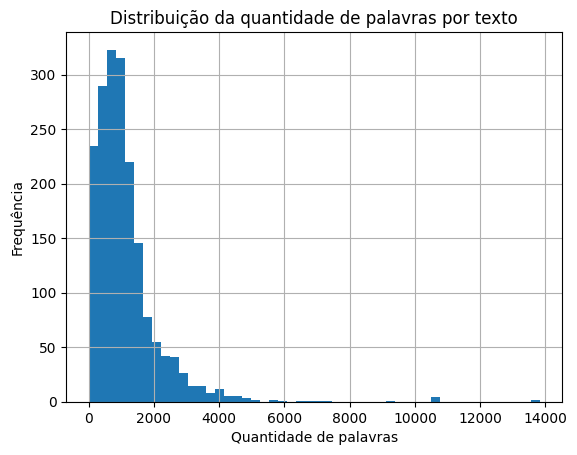

In [42]:
# Distribuição dos textos por quantidade de palavras 
df['contagem_palavras'].hist(bins=50)
plt.xlabel('Quantidade de palavras')
plt.ylabel('Frequência')
plt.title('Distribuição da quantidade de palavras por texto')
plt.show()

In [43]:
# Há textos em outra lingua ? 
# Fixa a semente para tornar a detecção determinística (reprodutível)
DetectorFactory.seed = 0

def detectar_idioma(texto):
    try:
        return detect(texto)
    except:
        return "erro"

nao_ingles = df[df['texto'].apply(detectar_idioma) != 'en']

nao_ingles.shape[0]

28

In [44]:
# Verificando os 28 registros 
nao_ingles[['id', 'categoria', 'subcategoria', 'texto']]

,id,categoria,subcategoria,texto
49,4132153,Frontend,frontend,{% embed https://dev.to/parsajiravand/you-cant...
74,4173833,Frontend,javascript,{% embed https://dev.to/anthonymax/typescript-...
84,4173937,Frontend,javascript,{% embed https://dev.to/anthonymax/typescript-...
194,4132153,Frontend,css,{% embed https://dev.to/parsajiravand/you-cant...
198,4127183,Frontend,css,{% embed https://dev.to/piyushpatil1243/glassm...
239,4173833,Frontend,typescript,{% embed https://dev.to/anthonymax/typescript-...
246,4173937,Frontend,typescript,{% embed https://dev.to/anthonymax/typescript-...
387,4160310,Backend,backend,{% embed https://dev.to/edpittol/your-fileexis...
585,4160310,Backend,php,{% embed https://dev.to/edpittol/your-fileexis...
761,4158249,Cloud,kubernetes,{% embed https://dev.to/zubairakbar/slurm-vs-k...


Ao aplicar o langdetect na coluna texto para conferir o campo 'language' da API, foram identificados 28 registros detectados como não sendo inglês.

Analisando esses registros, observamos que a maior parte já corresponde a casos identificados anteriormente nesta análise: registros do tipo placeholder ({% embed %} e {{ }}), registros com texto nulo, e registros que fazem parte do conflito de categoria (id repetido com categorias diferentes).

Apenas 1 registro (id 3523216, categoria DataScience, subcategoria pandas) apresenta um texto realmente em outro idioma (japonês), não relacionado a nenhum dos casos já mapeados.

## Preparação dos Dados

### Definindo Dataset


In [45]:
# Remoção inicial de colunas
df_clean = df.copy()

In [46]:
# Conferindo estrutura
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1851 entries, 0 to 1850
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1851 non-null   int64  
 1   categoria          1851 non-null   object 
 2   subcategoria       1851 non-null   object 
 3   texto              1848 non-null   object 
 4   tags               1851 non-null   object 
 5   contagem_palavras  1848 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 86.9+ KB


### Limpeza e Preparação dos Textos

#### Limpeza estrutural 

- Removendo nulos, duplicados, conflitos de id/categoria, placeholders sem conteúdo, textos curtos demais. 
- Garantir que cada linha é um registro único e válido

In [47]:
# Removendo registros nulos (3)
df_clean = df_clean.dropna(subset=["texto"])
df_clean.shape

(1848, 6)

Critério de resolução de conflitos | registros duplicados com mesmo id e texto, mas categoria/subcategoria diferente:

Durante a validação da amostra, cada categoria e subcategoria recebeu uma nota indicando o quanto o texto está relacionado a ela, além do percentual de nota 2 obtido em cada uma. Para decidir qual registro manter em caso de duplicidade, foram aplicadas as seguintes regras, em ordem de prioridade:

1. Manter o registro da subcategoria com maior percentual de nota 2
2. Em caso de empate, manter o registro da subcategoria com menor quantidade de registros
3. Persistindo o empate, manter o registro da categoria com menor quantidade de registros
4. Se ainda houver empate, a escolha é aleatória

Essas regras priorizam a subcategoria com melhor desempenho de validação, mais adequada para o treinamento do modelo, recorrendo aos demais critérios apenas quando necessário para desempate.

In [48]:
# Filtra subcategorias dos conflitos
subcategorias_conflito = df[df['id'].isin(ids_conflito)]['subcategoria'].unique().tolist()

print(subcategorias_conflito)

['javascript', 'react', 'typescript', 'nextjs', 'backend', 'springboot', 'java', 'api', 'php', 'cloud', 'aws', 'azure', 'docker', 'database', 'postgres', 'nosql', 'sql', 'mongodb', 'security', 'cybersecurity', 'infosec', 'datascience', 'machinelearning', 'python']


In [49]:
# Dicionário de regras (Chave = subcategoria)
# nota: Valor da nota conforme critério adotado na amostra - 2 = categoria correta
# qtd_sub: Quantidade de registros por subcategorias
# qtd_cat: Quantidade de registros por subcategorias

metrica_conflito = {
    'javascript': {'nota': 83.33, 'qtd_sub': 56, 'qtd_cat': 341},
    'react': {'nota': 100.0, 'qtd_sub': 27, 'qtd_cat': 341},
    'typescript': {'nota': 0.0, 'qtd_sub': 40, 'qtd_cat': 341},
    'nextjs': {'nota': 83.33, 'qtd_sub': 50, 'qtd_cat': 341},
    'backend': {'nota': 100.0, 'qtd_sub': 49, 'qtd_cat': 338},
    'springboot': {'nota': 100.0, 'qtd_sub': 45, 'qtd_cat': 338},
    'java': {'nota': 100.0, 'qtd_sub': 58, 'qtd_cat': 338},
    'api': {'nota': 100.0, 'qtd_sub': 52, 'qtd_cat': 338},
    'php': {'nota': 100.0, 'qtd_sub': 52, 'qtd_cat': 338},
    'cloud': {'nota': 100.0, 'qtd_sub': 58, 'qtd_cat': 287},
    'aws': {'nota': 100.0, 'qtd_sub': 59, 'qtd_cat': 287},
    'azure': {'nota': 100.0, 'qtd_sub': 59, 'qtd_cat': 287},
    'docker': {'nota': 100.0, 'qtd_sub': 53, 'qtd_cat': 287},
    'database': {'nota': 100.0, 'qtd_sub': 59, 'qtd_cat': 324},
    'postgres': {'nota': 100.0, 'qtd_sub': 56, 'qtd_cat': 324},
    'nosql': {'nota': 100.0, 'qtd_sub': 58, 'qtd_cat': 324},
    'sql': {'nota': 100.0, 'qtd_sub': 52, 'qtd_cat': 324},
    'mongodb': {'nota': 60.0, 'qtd_sub': 54, 'qtd_cat': 324},
    'security': {'nota': 100.0, 'qtd_sub': 60, 'qtd_cat': 346},
    'cybersecurity': {'nota': 100.0, 'qtd_sub': 58, 'qtd_cat': 346},
    'infosec': {'nota': 100.0, 'qtd_sub': 60, 'qtd_cat': 346},
    'datascience': {'nota': 100.0, 'qtd_sub': 58, 'qtd_cat': 215},
    'machinelearning': {'nota': 20.0, 'qtd_sub': 52, 'qtd_cat': 215},
    'python': {'nota': 100.0, 'qtd_sub': 58, 'qtd_cat': 215}
}

In [50]:
# Filtra registros com conflito
df_conflitos = df_clean[df_clean['id'].isin(ids_conflito)].sort_values('id')
len(df_conflitos)

153

In [51]:
# Visualizando conflitos antes da remoção 
df_conflitos.head(6)

,id,categoria,subcategoria,texto,tags,contagem_palavras
377,3509884,Backend,backend,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend",698.0
816,3509884,Cloud,aws,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend",698.0
800,3790359,Cloud,aws,"---\r\ndescription: ""SDAR claims it beats GRPO...","aws, machinelearning, mlops, reinforcementlear...",1444.0
1704,3790359,DataScience,machinelearning,"---\r\ndescription: ""SDAR claims it beats GRPO...","aws, machinelearning, mlops, reinforcementlear...",1444.0
1297,3965827,Security,security,"---\r\ntitle: ""Create and secure webhooks with...","api, webhooks, security, devtools",1998.0
511,3965827,Backend,api,"---\r\ntitle: ""Create and secure webhooks with...","api, webhooks, security, devtools",1998.0


Seguindo as regras definidas, o registro com index 800 (id 3790359) será mantido pois a subcategoria aws teve uma nota superior a subcategoria machinelearning 

In [52]:
# Obtem registros mantidos e removidos
registros_mantidos = {}   # Guarda o vencedor de cada um dos 71 IDs
registros_removidos = []  # Guarda os perdedores dos conflitos

# Inclui o index original (necessário para excluir os registros perdedores depois)
df_conflitos = df_conflitos.reset_index()

colunas_originais = ['index', 'id', 'categoria', 'subcategoria', 'texto', 'tags']

# 2. Percorre apenas as linhas dos 71 conflitos
for linha in df_conflitos.to_dict('records'):
    
    # BUSCA DIRETA NO DICIONÁRIO
    # Lê a subcategoria atual
    sub = linha['subcategoria']
    # Busca a nota e contagens no dicionário (usa nota 0 e qtd 99999 para penalizar desconhecidos)
    regras = metrica_conflito.get(sub, {'nota': 0, 'qtd_sub': 99999, 'qtd_cat': 99999})

    # Adiciona as métricas na linha atual
    linha['nota'] = regras['nota']
    linha['qtd_sub'] = regras['qtd_sub']
    linha['qtd_cat'] = regras['qtd_cat']

    id_atual = linha['id']

    # Se esse 'id' de conflito ainda não foi visto no laço:
    if id_atual not in registros_mantidos:
        registros_mantidos[id_atual] = linha
        
    # Se esse 'id' já está no dicionário -> Aplica a Regra de Desempate!
    else:
        registro_atual = registros_mantidos[id_atual]
        registro_novo = linha

        # --- ESTRUTURA DE COMPARAÇÃO ---
        # 1º Critério: Maior nota vence
        if registro_novo['nota'] > registro_atual['nota']:
            vencedor = registro_novo
            perdedor = registro_atual
        elif registro_novo['nota'] < registro_atual['nota']:
            vencedor = registro_atual
            perdedor = registro_novo
        else:
            # 2º Critério: Menor qtd de subcategoria vence
            if registro_novo['qtd_sub'] < registro_atual['qtd_sub']:
                vencedor = registro_novo
                perdedor = registro_atual
            elif registro_novo['qtd_sub'] > registro_atual['qtd_sub']:
                vencedor = registro_atual
                perdedor = registro_novo
            else:
                # 3º Critério: Menor qtd de categoria vence
                if registro_novo['qtd_cat'] < registro_atual['qtd_cat']:
                    vencedor = registro_novo
                    perdedor = registro_atual
                else:
                    vencedor = registro_atual
                    perdedor = registro_novo

        # Atualiza o vencedor e guarda o perdedor
        registros_mantidos[id_atual] = vencedor
        registros_removidos.append(perdedor)


In [53]:
# DataFrames finais
df_removidos = pd.DataFrame(registros_removidos)[colunas_originais]
len(df_removidos)

82

In [54]:
# Visualizando registros que serão removidos 
df_removidos.head()

,index,id,categoria,subcategoria,texto,tags
0,816,3509884,Cloud,aws,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
1,1704,3790359,DataScience,machinelearning,"---\r\ndescription: ""SDAR claims it beats GRPO...","aws, machinelearning, mlops, reinforcementlear..."
2,1297,3965827,Security,security,"---\r\ntitle: ""Create and secure webhooks with...","api, webhooks, security, devtools"
3,967,4056069,Database,database,I don lose count of how many times I don see t...,"backend, reviews, architecture, database"
4,286,4107706,Frontend,nextjs,\r\n\r\n## TL;DR\r\n\r\n- Best Sanity CMS use ...,"api, nextjs, saas, webdev"


Valindando que registro com id 3790359 e subcategoria machinelearning será desconsiderado 

In [55]:
df_mantidos = pd.DataFrame(list(registros_mantidos.values()))[colunas_originais]
len(df_mantidos)

71

In [56]:
# Visualizando registros que serão mantidos
df_mantidos.head()

,index,id,categoria,subcategoria,texto,tags
0,377,3509884,Backend,backend,> **One-liner:** Pub-Sub lets publishers broad...,"aws, systemdesign, devops, backend"
1,800,3790359,Cloud,aws,"---\r\ndescription: ""SDAR claims it beats GRPO...","aws, machinelearning, mlops, reinforcementlear..."
2,511,3965827,Backend,api,"---\r\ntitle: ""Create and secure webhooks with...","api, webhooks, security, devtools"
3,342,4056069,Backend,backend,I don lose count of how many times I don see t...,"backend, reviews, architecture, database"
4,516,4107706,Backend,api,\r\n\r\n## TL;DR\r\n\r\n- Best Sanity CMS use ...,"api, nextjs, saas, webdev"


Validando que registro com id 3790359 e subcategoria aws será mantido, conforme regras definidas 

In [57]:
# Quantidade de vezes que aparece o mesmo id 
df_mantidos.value_counts().value_counts().sort_index()

count
1    71
Name: count, dtype: int64

In [58]:
df_clean.shape

(1848, 6)

In [59]:
# Removendo registros com conflito (duplicados com id igual + texto igual + categoria | subcategoria diferente)
# Remove os registros perdedores definidos na resolução de conflitos, usando o índice original
df_clean = df_clean.drop(index=df_removidos['index'])
df_clean.shape

(1766, 6)

In [60]:
# Validando que todos foram removidos
df_clean.index.isin(df_removidos['index']).sum()

np.int64(0)

In [61]:
# Validando que todos foram mantidos 
df_clean.index.isin(df_mantidos['index']).sum()

np.int64(71)

In [62]:
# Há conflitos restantes? 
conflitos_restantes = df_clean[df_clean['id'].duplicated(keep=False)].groupby('id')['categoria'].nunique()
(conflitos_restantes > 1).sum()

np.int64(0)

As validações confirmam que os 71 registros definidos como vencedores foram mantidos, que os 82 registros com conflito foram removidos e que não restam mais categorias com esse tipo de conflito na base.

In [63]:
# Qtde registros duplicados por id, categoria e texto
duplicados_todos = df_clean.duplicated(subset=['id', 'categoria', 'texto'], keep=False)
duplicados_todos.sum()


np.int64(329)

In [64]:
# Verifica registros duplicados 
df_clean[duplicados_todos].sort_values('id').head(6)

,id,categoria,subcategoria,texto,tags,contagem_palavras
857,3450296,Cloud,azure,creating a folder and initializing github for ...,"devops, azure, cloud, cloudcomputing",240.0
718,3450296,Cloud,cloud,creating a folder and initializing github for ...,"devops, azure, cloud, cloudcomputing",240.0
1225,4033011,Database,mongodb,"For a long time, my comfort zone was built on ...","mongodb, scalingdiaries, vectorsearch, nosql",573.0
1094,4033011,Database,nosql,"For a long time, my comfort zone was built on ...","mongodb, scalingdiaries, vectorsearch, nosql",573.0
1220,4057283,Database,mongodb,\r\n![Image description](https://dev-to-upload...,"scalingdiaries, mongodb, nosql, databasedesign",919.0
1093,4057283,Database,nosql,\r\n![Image description](https://dev-to-upload...,"scalingdiaries, mongodb, nosql, databasedesign",919.0


Nesse caso, não é necessário avaliar a nota da subcategoria para descartar os registros, pois os registros duplicados pertencem à mesma categoria. A duplicidade ocorre porque cada artigo pode ter até 4 tags diferentes associadas a ele, e as consultas na coleta de dados são feitas por subcategoria, fazendo com que o mesmo artigo apareça mais de uma vez na base. Serão mantidos os registros da primeira ocorrência de cada registro duplicado.

In [65]:
# Quantidade de registros duplicados por id, categoria e texto - desconsiderando a 1ª ocorrência de cada grupo)
duplicados_remover = df_clean.duplicated(subset=['id', 'categoria', 'texto'], keep='first')
duplicados_remover.sum()

np.int64(171)

In [66]:
df_clean.shape

(1766, 6)

In [67]:
# Removendo registros com id, categoria e texto iguais - mantendo apenas a 1ª ocorrência
df_clean = df_clean.sort_values('id')[~duplicados_remover]
df_clean.shape

C:\Users\Patricia\AppData\Local\Temp\ipykernel_11056\3472753471.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df_clean.sort_values('id')[~duplicados_remover]


(1595, 6)

Removeu os 171 registros 

In [68]:
# Quantos registros com texto somente com marcação sobraram
padroes_ruins_clean = df_clean['texto'].astype(str).str.match(r'^\s*(\{\{.*\}\}|\{%.*%\})\s*$')
padroes_ruins_clean.sum()

np.int64(19)

In [69]:
# Removendo registros com texto igual a marcação placeholder/embed (sem conteúdo real)
df_clean = df_clean[~padroes_ruins_clean]
df_clean.shape

(1576, 6)

In [70]:
# Quantos registros com texto duplicado e id diferente ainda existem
grupos_id_diferente_2 = df_clean[df_clean['texto'].duplicated(keep=False)].groupby('texto')['id'].nunique()
textos_id_diferente_2 = grupos_id_diferente_2[grupos_id_diferente_2 > 1].index

len(textos_id_diferente_2)

4

In [71]:
# Visualizando registros
df_clean[df_clean['texto'].isin(textos_id_diferente_2)].sort_values('texto')[['id', 'categoria', 'subcategoria', 'texto']]

,id,categoria,subcategoria,texto
1269,1819628,Database,crud,\r\n\r\nI'm setting up a CRUD system with Djan...
1270,1819629,Database,crud,\r\n\r\nI'm setting up a CRUD system with Djan...
1586,4040607,Security,ethicalhacking,# The Step-by-Step Process of Penetration Test...
1591,4040758,Security,ethicalhacking,# The Step-by-Step Process of Penetration Test...
1173,4153247,Database,sql,Most data questions start in plain English.\r\...
1181,4153348,Database,sql,Most data questions start in plain English.\r\...
1372,3066817,Security,mfa,Online security is a top priority for business...
1371,3096643,Security,mfa,Online security is a top priority for business...


In [72]:
# Remove registros com texto duplicado e id diferente
duplicata_a_remover = df_clean['texto'].isin(textos_id_diferente_2) & df_clean.duplicated(subset=['texto'], keep='first')

df_clean = df_clean[~duplicata_a_remover]

df_clean.shape

(1572, 6)

In [73]:
# Conferindo que não há mais registros com texto duplicado e id diferente 
grupos_id_diferente_2 = df_clean[df_clean['texto'].duplicated(keep=False)].groupby('texto')['id'].nunique()
textos_id_diferente_2 = grupos_id_diferente_2[grupos_id_diferente_2 > 1].index

len(textos_id_diferente_2)

0

In [74]:
# Removendo o único registro identificado com texto em idioma diferente de inglês (japonês)
df_clean = df_clean[df_clean['id'] != 3523216]
df_clean.shape

(1571, 6)

In [75]:
# Quantidade com textos com menos de 20 palavras
df_clean['contagem_palavras'] = df_clean['texto'].str.split().str.len()

(df_clean['contagem_palavras'] < 20).sum()

np.int64(0)

In [76]:
# Distribuição atual 
df_clean['categoria'].value_counts()

categoria
Backend        319
Security       304
Database       270
Frontend       253
Cloud          240
DataScience    185
Name: count, dtype: int64

Após limpeza inicial, há 1571 registros distribuidos nas 6 categorias

#### Limpeza de marcações e caracteres não semânticos

- Identificação de padrões residuais (front matter, código, URLs, HTML, emojis, etc.)
- Definição das regras de limpeza (regex)
- Aplicação da limpeza no texto

In [77]:
# Verificando a quantidade de padrões nos textos para obter um de exmeplo 
def contar_padroes(texto):
    padroes = {
        'front_matter': len(re.findall(r'^\s*---.*?---', texto, flags=re.DOTALL)),
        'urls': len(re.findall(r'https?://\S+', texto)),
        'links_md': len(re.findall(r'\[.*?\]\(.*?\)', texto)),
        'imagens_md': len(re.findall(r'!\[.*?\]\(.*?\)', texto)),
        'embeds': len(re.findall(r'\{%.*?%\}|\{\{.*?\}\}', texto)),
        'codigo': len(re.findall(r'```.*?```', texto, flags=re.DOTALL)),
        'html': len(re.findall(r'<[^>]+>', texto)),
    }
    return sum(padroes.values())

df_clean['score_sujeira'] = df_clean['texto'].apply(contar_padroes)

df_clean.sort_values('score_sujeira', ascending=False)[['id', 'categoria', 'score_sujeira']].head(10)

,id,categoria,score_sujeira
88,4168792,Frontend,1063
89,4168795,Frontend,965
87,4168804,Frontend,931
90,4168793,Frontend,776
677,4151356,Backend,739
1278,1630734,Database,557
138,4167010,Frontend,544
112,4168806,Frontend,465
1596,4006572,Security,464
1260,2010871,Database,287


In [78]:
# Visualizando o caso com mais padrões 
id_referencia = 4168792

print(df_clean.loc[df_clean['id'] == id_referencia, 'texto'].values[0])

---
title: React Native Interview Handbook — Part 3 of 10: React Native
published: true
description: 200 React Native interview questions on navigation, state, APIs, performance, native modules, and New Architecture.
tags: reactnative, javascript, react, career
series: Complete React Native Interview Handbook 2026
---

This guide is part of a **719-question React Native interview handbook** collected from real interviews across startups, product companies, fintech, e-commerce, and MNCs. Questions range from beginner to senior (5+ years) and cover JavaScript, React Native, New Architecture, performance, security, native modules, iOS, Android, system design, and behavioral interviews.

This article contains **200 questions** (global questions 221–420). Answer each question before reading the response, explain assumptions and complexity for coding questions, and adapt behavioral examples to your truthful experience.

## Difficulty guide

- 🟢 **Beginner** — expected for entry-level and jun

In [79]:
regras_limpeza = [
    (r'^\s*---.*?---\s*', '', re.DOTALL),                                          # Front matter
    (r'```.*?```', '', re.DOTALL),                                                 # Blocos de código
    (r'!\[.*?\]\(.*?\)', '', 0),                                                   # Imagens
    (r'\[([^\]]*)\]\(.*?\)', r'\1', 0),                                            # Links
    (r'https?://\S+', '', 0),                                                      # URLs
    (r'\{%.*?%\}|\{\{.*?\}\}', '', 0),                                             # Shortcodes
    (r'<!--.*?-->', '', re.DOTALL),                                                # Comentários HTML
    (r'<[^>]+>', '', 0),                                                           # Tags HTML
    (r'\p{Emoji}', '', 0),                                                         # Emojis (inclui 🟢 🟡 🔴)
    (r'\d+(\.\d+)*', '', 0),                                                       # Números (incluindo versões tipo 0.82)
    (r'(?<![a-zA-Z0-9])(\+\+|#)(?![a-zA-Z0-9])|[^\w\s\+\#\.\-]', '', 0),           # Pontuação (preserva C++, C#, .NET, Node.js)
    (r'(?<!\w)\.(?!\w)', '', 0),                                                   # Remove pontos órfãos (sobra de número removido)
    (r'\n{2,}', '\n', 0),                                                          # Quebras extras
    (r' {2,}', ' ', 0),                                                            # Espaços extras
]

def limpar_texto(texto):
    if not isinstance(texto, str):
        return ""

    texto = texto.lower()  # Lowercase

    for padrao, substituicao, flags in regras_limpeza:
        texto = re.sub(padrao, substituicao, texto, flags=flags)

    return texto.strip()

In [80]:
# Teste limpeza do texto referencia 
print(limpar_texto(df_clean.loc[df_clean['id'] == id_referencia, 'texto'].values[0]))

this guide is part of a -question react native interview handbook collected from real interviews across startups product companies fintech e-commerce and mncs. questions range from beginner to senior + years and cover javascript react native new architecture performance security native modules ios android system design and behavioral interviews.

this article contains questions global questions answer each question before reading the response explain assumptions and complexity for coding questions and adapt behavioral examples to your truthful experience.

 difficulty guide

- beginner expected for entry-level and junior react native roles.
- intermediate expected for engineers who can independently ship features.
- senior tests architecture trade-offs production ownership and native-platform knowledge.

 topics in this part

- react native basics questions 
- components layout navigation and state management
- apis networking and offline storage
- performance profiling native modules 

Podemos verificar que o texto foi limpo e mantém a semântica que caracteriza a categoria Frontend. Termos técnicos centrais como react native, flatlist, redux, jsi, hermes, turbomodule e codegen permaneceram preservados, mesmo após a remoção de front matter, blocos de código, marcações HTML, emojis, URLs, pontuação e números. Esses termos possuem alta capacidade discriminativa e tendem a contribuir positivamente para a classificação via TF-IDF.

In [81]:
# Teste Limpa textos 
df_clean['texto_teste'] = df_clean['texto'].apply(limpar_texto)

In [82]:
# Conferindo remoção
print(df_clean.loc[df_clean['id'] == id_referencia, 'texto_teste'].values[0])

this guide is part of a -question react native interview handbook collected from real interviews across startups product companies fintech e-commerce and mncs. questions range from beginner to senior + years and cover javascript react native new architecture performance security native modules ios android system design and behavioral interviews.

this article contains questions global questions answer each question before reading the response explain assumptions and complexity for coding questions and adapt behavioral examples to your truthful experience.

 difficulty guide

- beginner expected for entry-level and junior react native roles.
- intermediate expected for engineers who can independently ship features.
- senior tests architecture trade-offs production ownership and native-platform knowledge.

 topics in this part

- react native basics questions 
- components layout navigation and state management
- apis networking and offline storage
- performance profiling native modules 

In [83]:
# Verificando se ficou algum ruido
df_clean['score_sujeira_teste'] = df_clean['texto_teste'].apply(contar_padroes)

df_clean.sort_values('score_sujeira_teste', ascending=False)[['id', 'categoria', 'score_sujeira_teste']].head(10)

,id,categoria,score_sujeira_teste
777,4150591,Cloud,1
882,4172681,Cloud,1
1707,4177197,DataScience,0
1383,1127160,Security,0
517,4176870,Backend,0
1317,4176892,Security,0
341,4176919,Backend,0
343,4176948,Backend,0
1802,4176961,DataScience,0
1797,4176964,DataScience,0


Ao recalcular o score_sujeira após a limpeza, restaram apenas 2 registros com resíduo (score 1), contra um máximo de 1063 antes da limpeza, confirmando que a limpeza estrutural foi eficaz na quase totalidade da base. 

In [84]:
# Verificando os resíduos 
print(df_clean.loc[df_clean['id'] == 4150591, 'texto_teste'].values[0])

---
title monorepo is not monolith and the difference decides your cve response time
published false
description repo layout and runtime topology are orthogonal axes. heres what each one actually costs you in version control updates scaling and scanning.
tags architecture devops security kubernetes
cover_image 
canonical_url 
---
repo layout and deployment topology are orthogonal. most orgs conflate them split their runtime to solve a version-control problem and end up with a distributed monolith that fails together deploys together and now also drops packets.

the decision that actually matters is where you enforce a boundary compiler or network and you make that choice once per boundary not once per company.

 the two axes




fig. the four real options. monorepo vs. microservices is a category error.

 axis question it answers reversible 
---------
 source layout monopoly-repo how do teams land code yes painful but mechanical 
 deployment unit monolithservices what ships and scales 

O texto limpo do id 4150591 ainda contem informações do bloco de front matter completo (title, published, description, tags, cover_image, canonical_url), além de sequências de hífens usadas como separadores de tabela markdown ao longo do texto, sem valor semântico para o modelo.

In [85]:
# Verificando o texto original 
df_clean.loc[df_clean['id'] == 4150591, 'texto'].values[0][:50]

'\r\n![cover image](https://dev-to-uploads.s3.us-east'

Investigando o id 4150591, identificamos que o front matter não foi removido porque o texto original inicia com uma imagem markdown antes do bloco ---...--- , o que quebra a âncora de início (^) usada na regra de remoção do front matter. Esse caso será corrigido em uma revisão da regra.

Investigando o id 4150591, identificamos duas causas de resíduo:

* O texto original inicia com uma imagem markdown antes do bloco ---...---, o que quebrava a âncora de início (^) usada na regra de remoção do front matter
* O texto contém múltiplas sequências de hífens usadas como separadores de tabela, que não eram cobertas por nenhuma regra existente

Ambos os casos serão corrigidos em um revisão da regra 

In [86]:
# Verificando o segundo ruído 
print(df_clean.loc[df_clean['id'] == 4172681, 'texto_teste'].values[0])

---
title azure multi-platform infrastructure cluster automation deployment guide
published false
tags ansible azure devops automation

---


this repository contains the complete configuration management architecture and deployment runbooks for orchestrating a heterogeneous cross-platform infrastructure environment via ansible core 

the pipeline automates the teardown of conflicting runtime contexts maps local file parameters dynamically into linux containers using jinja templates and uses winrm over https to provision web server features on windows targets via native system managers.

---

 cloud architecture specifications

this automation pipeline explicitly targets a multi-platform compute matrix provisioned across separate distinct virtual machine resources in microsoft azure

 core infrastructure nodes

 ansible control node vm ubuntu lts acting as execution host running python and pywinrm
 linux managed target vm ubuntu lts running docker engine for containerized services
 int

In [87]:
# Verificando inicio do texto original 
df_clean.loc[df_clean['id'] == 4172681, 'texto'].values[0][:50]

'\r\n![Image description](https://dev-to-uploads.s3.u'

O motivo dos dois ruídos é o mesmo. 

In [88]:
# Atualizando regra de limpeza
regras_limpeza = [
    (r'^\s*(!\[.*?\]\(.*?\)\s*)?---.*?---\s*', '', re.DOTALL),                     # Front matter (tolera imagem antes)
    (r'-{3,}', '', 0),                                                            # Sequências de hífens (separadores de tabela/seção)
    (r'```.*?```', '', re.DOTALL),                                                 # Blocos de código
    (r'!\[.*?\]\(.*?\)', '', 0),                                                   # Imagens
    (r'\[([^\]]*)\]\(.*?\)', r'\1', 0),                                            # Links
    (r'https?://\S+', '', 0),                                                      # URLs
    (r'\{%.*?%\}|\{\{.*?\}\}', '', 0),                                             # Shortcodes
    (r'<!--.*?-->', '', re.DOTALL),                                                # Comentários HTML
    (r'<[^>]+>', '', 0),                                                           # Tags HTML
    (r'\p{Emoji}', '', 0),                                                         # Emojis (inclui 🟢 🟡 🔴)
    (r'\d+(\.\d+)*', '', 0),                                                       # Números (incluindo versões tipo 0.82)
    (r'(?<![a-zA-Z0-9])(\+\+|#)(?![a-zA-Z0-9])|[^\w\s\+\#\.\-]', '', 0),           # Pontuação (preserva C++, C#, .NET, Node.js)
    (r'(?<!\w)\.(?!\w)', '', 0),                                                   # Remove pontos órfãos (sobra de número removido)
    (r'\n{2,}', '\n', 0),                                                          # Quebras extras
    (r' {2,}', ' ', 0),                                                            # Espaços extras
]

A regra de front matter passou a tolerar uma imagem opcional antes do bloco, e uma nova regra foi adicionada para remover sequências de 3 ou mais hífens em qualquer parte do texto.

In [89]:
# Teste Limpa textos 
df_clean['texto_teste'] = df_clean['texto'].apply(limpar_texto)

In [90]:
# Conferindo texto de referencia 
print(df_clean.loc[df_clean['id'] == id_referencia, 'texto_teste'].values[0])

this guide is part of a -question react native interview handbook collected from real interviews across startups product companies fintech e-commerce and mncs. questions range from beginner to senior + years and cover javascript react native new architecture performance security native modules ios android system design and behavioral interviews.

this article contains questions global questions answer each question before reading the response explain assumptions and complexity for coding questions and adapt behavioral examples to your truthful experience.

 difficulty guide

- beginner expected for entry-level and junior react native roles.
- intermediate expected for engineers who can independently ship features.
- senior tests architecture trade-offs production ownership and native-platform knowledge.

 topics in this part

- react native basics questions 
- components layout navigation and state management
- apis networking and offline storage
- performance profiling native modules 

In [91]:
# Verificando texto do primeiro ruido
print(df_clean.loc[df_clean['id'] == 4150591, 'texto_teste'].values[0])

repo layout and deployment topology are orthogonal. most orgs conflate them split their runtime to solve a version-control problem and end up with a distributed monolith that fails together deploys together and now also drops packets.

the decision that actually matters is where you enforce a boundary compiler or network and you make that choice once per boundary not once per company.

 the two axes




fig. the four real options. monorepo vs. microservices is a category error.

 axis question it answers reversible 

 source layout monopoly-repo how do teams land code yes painful but mechanical 
 deployment unit monolithservices what ships and scales independently no data migrations arent git revert 


asymmetry of regret. repo layout is a two-way door. runtime topology is a one-way door the moment each service owns its data. sequence accordingly change the repo layout first and only split the runtime once module boundaries have proven stable in a monolith.



because it arrives by acc

In [92]:
# Verificando texto do segundo ruido
print(df_clean.loc[df_clean['id'] == 4172681, 'texto_teste'].values[0])

this repository contains the complete configuration management architecture and deployment runbooks for orchestrating a heterogeneous cross-platform infrastructure environment via ansible core 

the pipeline automates the teardown of conflicting runtime contexts maps local file parameters dynamically into linux containers using jinja templates and uses winrm over https to provision web server features on windows targets via native system managers.



 cloud architecture specifications

this automation pipeline explicitly targets a multi-platform compute matrix provisioned across separate distinct virtual machine resources in microsoft azure

 core infrastructure nodes

 ansible control node vm ubuntu lts acting as execution host running python and pywinrm
 linux managed target vm ubuntu lts running docker engine for containerized services
 internal private ip 
 external public ip 
 windows managed target vm windows server datacenter running native iis features
 internal private ip 
 ex

In [93]:
# Verificando se ficou algum ruido
df_clean['score_sujeira_teste'] = df_clean['texto_teste'].apply(contar_padroes)

df_clean.sort_values('score_sujeira_teste', ascending=False)[['id', 'categoria', 'score_sujeira_teste']].head(10)

,id,categoria,score_sujeira_teste
1383,1127160,Security,0
1398,1165812,Security,0
1397,1213880,Security,0
1396,1281254,Security,0
1395,1301498,Security,0
1394,1314783,Security,0
1393,1363498,Security,0
1289,1401821,Database,0
1392,1413413,Security,0
1288,1474491,Database,0


Após confirmar visualmente que os registros com resíduo (ids 4150591 e 4172681) tiveram o front matter e os separadores de tabela corretamente removidos, recontamos o score_sujeira em toda a base para validar a limpeza de forma abrangente. O resultado confirma score 0 em todos os registros, sem exceção.

In [94]:
# Atualizando o texto com a versão limpa  
df_clean['texto'] = df_clean['texto_teste']
df_clean = df_clean.drop(columns=['texto_teste', 'score_sujeira', 'score_sujeira_teste'], errors='ignore')

#### Pré-processamento com NLP

- Remoção de stopwords
- Lemmatização

In [95]:
# Carrega o modelo de linguagem em inglês do spaCy
nlp = spacy.load("en_core_web_sm")

In [96]:
# Stopwords adicionais não cobertas pela lista padrão do spaCy
stopwords_extra = {"yes", "ok", "okay", "sure", "hey", "hi"}

In [97]:
# Realizando tokenização, remoção de stopwords e lemmatização
# Retorna o texto pronto para o TF-IDF
def preprocessar_nlp(texto):
    # processa e tokeniza
    doc = nlp(texto)
    
    tokens = [
        # forma lematizada (base) de cada palavra
        token.lemma_

        # para cada token, verifica se não é stopword e não é só espaço 
        for token in doc
        if not token.is_stop 
        and not token.is_space 
        and token.lemma_.strip() != ''
        and token.lemma_.lower() not in stopwords_extra
    ]
    
    return ' '.join(tokens)

In [98]:
# Só para visualização - mantém quebras de linha originais
texto_original = df_clean.loc[df_clean['id'] == id_referencia, 'texto'].values[0]
for linha in texto_original.split('\n'):
    if linha.strip():
        print(preprocessar_nlp(linha))

guide -question react native interview handbook collect real interview startup product company fintech e - commerce mnc . question range beginner senior + year cover javascript react native new architecture performance security native module ios android system design behavioral interview .
article contain question global question answer question read response explain assumption complexity cod question adapt behavioral example truthful experience .
difficulty guide
- beginner expect entry - level junior react native role .
- intermediate expect engineer independently ship feature .
- senior test architecture trade - offs production ownership native - platform knowledge .
topic
- react native basic question
- component layout navigation state management
- apis networking offline storage
- performance profile native module fabric turbomodule jsi
- native android ios integration
- animation push notification
complete series
dev.to series core handbook article plus focus practice extras . o

Aplicamos o pré-processamento com NLP (spaCy) no texto de referência: tokenização, remoção de stopwords e lemmatização. O vocabulário técnico (turbomodule, codegen, jsi, react native, flatlist, c++) continuou preservado, e palavras que não ajudam a identificar o assunto (the, is, a, and, how do you) foram removidas.

Algumas palavras ficaram com lematização estranha (ex: "hermes" virou "herme", "data" virou "datum"), o que é normal ao usar um modelo genérico de inglês em texto técnico. Acreditamos não ser um problema real, já que essas variações aparecem sempre da mesma forma no texto e não atrapalham o TF-IDF.

In [99]:
# Aplicando na base 
df_clean['texto'] = df_clean['texto'].apply(preprocessar_nlp)

In [100]:
# Comparando quantidade média de palavras antes e depois do pré-processamento NLP
pd.DataFrame({
    'antes': [df_clean['contagem_palavras'].mean()],
    'depois': [df_clean['texto'].str.split().str.len().mean()]
})

,antes,depois
0,1130.392107,621.204965


Após aplicar o pré-processamento com NLP na base inteira, comparamos a quantidade média de palavras por texto antes e depois: caiu de ~1130 para ~610 palavras, uma redução de quase 45%. O resultado é consistente com o esperado, já que stopwords costumam representar entre 30% e 45% do volume de um texto em inglês.

In [101]:
# Recalculando contagem de textos com menos de palavras após o pré-processamento NLP
df_clean['contagem_palavras_final'] = df_clean['texto'].str.split().str.len()

(df_clean['contagem_palavras_final'] < 20).sum()

np.int64(7)

In [102]:
# Verificando registros com menos de 20 palavras após limpeza
df_clean[df_clean['contagem_palavras_final'] < 20][['id', 'categoria', 'contagem_palavras', 'contagem_palavras_final', 'texto']]

,id,categoria,contagem_palavras,contagem_palavras_final,texto
1263,1952170,Database,80,14,update prisma typegraphql - prisma - nestjs sy...
1633,3453189,Security,20,11,read hackersprey late blog network security fa...
1134,3587786,Database,33,13,quick reference guide redis cover core concept...
1764,3712690,DataScience,212,0,
1599,3962333,Security,2055,0,
1590,3986760,Security,2181,0,
191,4151028,Frontend,561,0,


In [103]:
# Verificando como eram os textos originais dos 4 registros que ficaram sem conteúdo após a limpeza
ids_investigar = [3712690, 3962333, 3986760, 4151028]

textos_investigar = df.loc[df['id'].isin(ids_investigar)].set_index('id')['texto'].to_dict()

df.loc[df['id'].isin(ids_investigar), ['id', 'categoria', 'texto']]

,id,categoria,texto
191,4151028,Frontend,---\r\n\r\nThe Stroop Effect is one of the mos...
1590,3986760,Security,```markdown\r\n# Why Ethical Hacking is a Grea...
1599,3962333,Security,```markdown\r\n---\r\ntitle: Mastering Cyberse...
1764,3712690,DataScience,"\r\n```shell\r\nEvery month, the same thing ha..."


Ao recontar a quantidade de palavras após o pré-processamento, identificamos 7 registros com menos de 20 palavras (o corte mínimo definido para o treino). Desses, 4 ficaram com o texto completamente vazio (0 palavras).

Necessário investigar cada caso para confirmar os motivos da exclusão total e garantir que as regras de limpeza estão adequadas.

In [104]:
# Verifica as ocorrências do padrão de delimitação em cada um dos 4 textos
resultados = []

for id_registro, texto in textos_investigar.items():
    padrao = '---' if id_registro == 4151028 else '```'
    posicoes = [m.start() for m in re.finditer(padrao, texto)]
    
    resultados.append({
        'id': id_registro,
        'padrao': padrao,
        'ocorrencias': len(posicoes),
        'posicoes': posicoes,
        'tamanho_texto': len(texto)
    })

pd.DataFrame(resultados)

,id,padrao,ocorrencias,posicoes,tamanho_texto
0,4151028,---,2,"[0, 3476]",3479
1,3986760,```,2,"[0, 16662]",16665
2,3962333,```,2,"[0, 15639]",15642
3,3712690,```,2,"[2, 1555]",1558


A verificação confirma a mesma causa nos 4 registros: em cada um, o padrão de delimitação (--- ou ```) aparece apenas duas vezes no texto, sendo uma no início e outra próxima ao final, englobando praticamente todo o conteúdo. 

No id 4151028, o autor provavelmente usou "---" apenas como uma linha divisória no início do texto, sem a intenção de indicar front matter. Como a regra de limpeza remove tudo entre a primeira e a última ocorrência de "---", o artigo inteiro acabou sendo apagado.

Nos ids 3986760, 3962333 e 3712690, o artigo inteiro foi escrito dentro de um único bloco de código markdown, ao invés de conter apenas trechos pontuais de código. Como a regra de limpeza remove blocos de código por completo, cada um desses artigos foi eliminado inteiramente.


Solução:

Como são casos isolados (4 de aproximadamente 1800 registros), causados por formatações atípicas dos autores originais e não por falha na lógica das regras, optamos por não alterá-las. O ajuste traria risco de comprometer o funcionamento correto nos demais registros da base. Esses registros, junto aos demais 3 com menos de 20 palavras após o pré-processamento, serão removidos, seguindo o critério já definido para o conjunto de dados.

In [105]:
# Removendo registros com menos de 20 palavras após o pré-processamento NLP
df_clean = df_clean[df_clean['contagem_palavras_final'] >= 20]
df_clean.shape

(1564, 7)

In [106]:
# Consultando distribuição atual 
df_clean['categoria'].value_counts()

categoria
Backend        319
Security       301
Database       268
Frontend       252
Cloud          240
DataScience    184
Name: count, dtype: int64

## Gerando Base para Treino e Teste

In [107]:
# Gerando arquivo csv com base limpa para treino e teste 
# Gerando arquivo csv com a base limpa, contendo apenas texto e categoria
df_clean[['texto', 'categoria']].to_csv('../dados/base_techmind.csv', index=False, encoding='utf-8')

## Conclusões

A base final ficou com 1.564 registros, distribuídos em 6 categorias (Backend, Security, Database, Frontend, Cloud e DataScience), prontos para a etapa de modelagem.

O processo de limpeza envolveu: 

* remoção de registros nulos e placeholders sem conteúdo real
* resolução de 82 registros em conflito de categoria (mantendo 71 vencedores, conforme critério de nota por subcategoria definido com o time)
* remoção de duplicatas por id, categoria e texto
* remoção de textos idênticos associados a ids diferentes
* exclusão de um registro em idioma não inglês
* limpeza estrutural de marcações residuais (front matter, blocos de código, URLs, HTML, emojis)
* pré-processamento com NLP (tokenização, remoção de stopwords e lematização via spaCy).

Ao longo do processo, identificamos e documentamos algumas limitações pontuais das regras de limpeza, como blocos de código markdown que continham o artigo inteiro, decidindo não lterá-las por afetarem poucos registros isolados.

Os dados tratados foram exportados para base_techmind.csv, contendo apenas as colunas texto e categoria, utilizadas na etapa de modelagem.